# Plot observations in unsaturated zone

In [1]:
import hydropandas as hpd
import matplotlib.pyplot as plt

import pandas as pd

In [2]:
hpd.__version__


'0.18.1'

# Load data

In [3]:
DATA_DIR = r"../data//"
PLOT_DIR = r"plots//"

In [4]:
oc = hpd.read_pickle(DATA_DIR + "oc_unsat.pkl")
# renamed to oc_unsat.pkl in c:\data\python\cloned\voorverkenning\data

# Example of content of HydroPandas Observation Collection

## Make a plot of timeseries
Most sensors have two columns. The 'basic' paramater (soil moisture) and temperature.

Text(0.5, 0.98, 'Observations Os966,50_BIT1_SM_0.23\nThe 0th row of observation collection ')

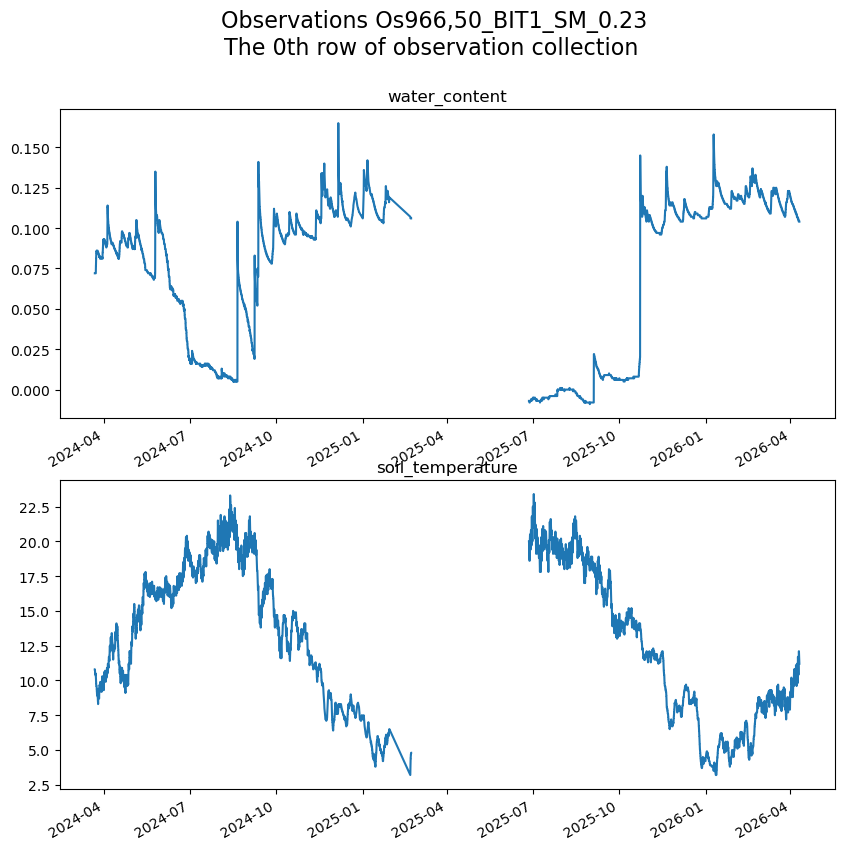

In [5]:
id = 0
fig, axes = plt.subplots(len(oc.iloc[id].obs.columns), 1, figsize=(10, 5 * len(oc.iloc[id].obs.columns)))
if len(oc.iloc[id].obs.columns) == 1:
    axes = [axes]
for i, col in enumerate(oc.iloc[id].obs.columns):
    oc.iloc[id].obs[col].plot(ax=axes[i])
    axes[i].set_title(col)
fig.suptitle(f"Observations {oc.index[id]}\nThe {id}th row of observation collection ", fontsize=16)


## Metadata

The observation collection also holds metainfo.

In [6]:
print(f'Metadata of row {id} in ObsCollection\n' \
      f' - Name: {oc.index[id]}\n' \
      f' - That is in area: {oc.iloc[id].region} at dikepole: {oc.iloc[id].sensor_dp} position on levee: {oc.iloc[id].sensor_position_name}\n' \
      f'   sensor type: {oc.iloc[id].sensor_type}\n' \
      f'   depth of sensor is: {oc.iloc[id].screen_top} m below ground level\n' \
      f' - For plotting we group sensor via `raai_dp`: {oc.iloc[id].raai_dp}'
      )

Metadata of row 0 in ObsCollection
 - Name: Os966,50_BIT1_SM_0.23
 - That is in area: Os at dikepole: 966.5 position on levee: BIT1
   sensor type: soil moisture
   depth of sensor is: 0.23 m below ground level
 - For plotting we group sensor via `raai_dp`: 966.5


Overview of all data for a sensor.

In [7]:
oc.iloc[id]

x                                                                                 62639
y                                                                                396191
location                                                               Os966,50_BIT1_SM
filename                                                                               
source                                                                                 
unit                                                                                   
tube_nr                                                                                
screen_top                                                                         0.23
screen_bottom                                                                      0.23
ground_level                                                                        NaN
tube_top                                                                            NaN
metadata_available              

## Advanced plotting

The `section_plot` make a plot of timeseries with some extra info in the first plot. 

Here a plot of all sensors at one location.

(<Figure size 1500x500 with 2 Axes>,
 [<Axes: xlabel='Depth of sensor (m below ground level)'>, <Axes: >])

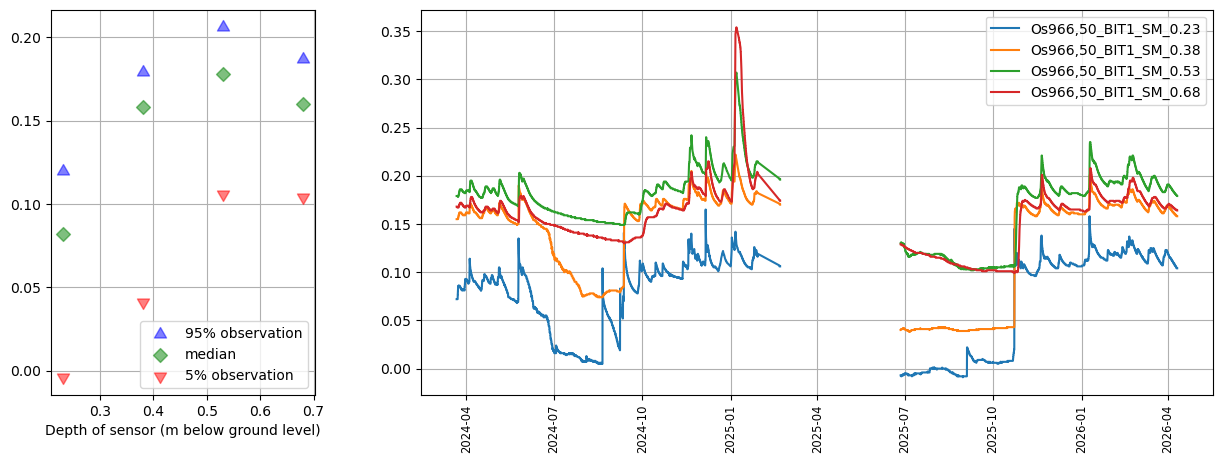

In [8]:
oc.loc[
    (oc.sensor_dp == oc.iloc[id].sensor_dp) &
    (oc.sensor_position_name == oc.iloc[id].sensor_position_name)
    ].plots.section_plot(
        section_colname_x="screen_top",
        section_label_x="Depth of sensor (m below ground level)",
    )

## Some stats

HydroPandas has some stats included.

In [9]:
oc.stats.get_first_last_obs_date()

,date_first_measurement,date_last_measurement
name,,
"Os966,50_BIT1_SM_0.23",2024-03-22,2026-05-18 05:00:00
"Os966,50_BIT1_SM_0.38",2024-03-22,2026-05-18 05:00:00
"Os966,50_BIT1_SM_0.53",2024-03-22,2026-05-18 05:00:00
"Os966,50_BIT1_SM_0.68",2024-03-22,2026-05-18 05:00:00
"Os966,50_BIT2_SM_0.23",2024-03-22,2026-05-18 05:00:00
...,...,...
"WsN754,43_KR_SM_0.68",2024-02-08,2026-05-18 05:00:00
"WsN754,49_KR_SM_0.23",2024-02-08,2026-05-18 05:00:00
"WsN754,49_KR_SM_0.38",2024-02-08,2026-05-18 05:00:00


Plot period. Basic layout. Better plotting for time on x-axis. For now okay.

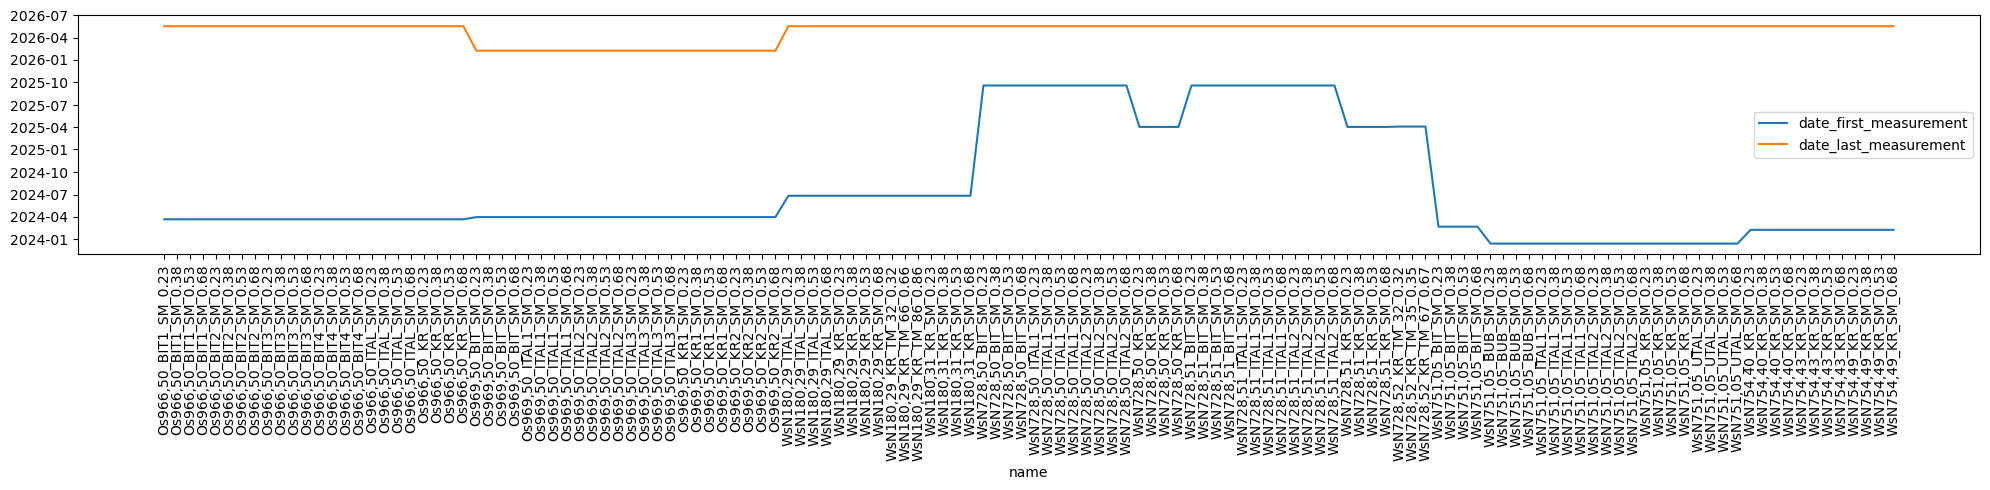

In [10]:
oc.stats.get_first_last_obs_date().plot(figsize=(20, 5))
plt.xticks(ticks=range(len(oc.index)), labels=oc.index, rotation=90)
plt.tight_layout()
plt.show()

# Real analysis

Use power of an Observation Collection to make usefull plots.

## Plot all data of one raai

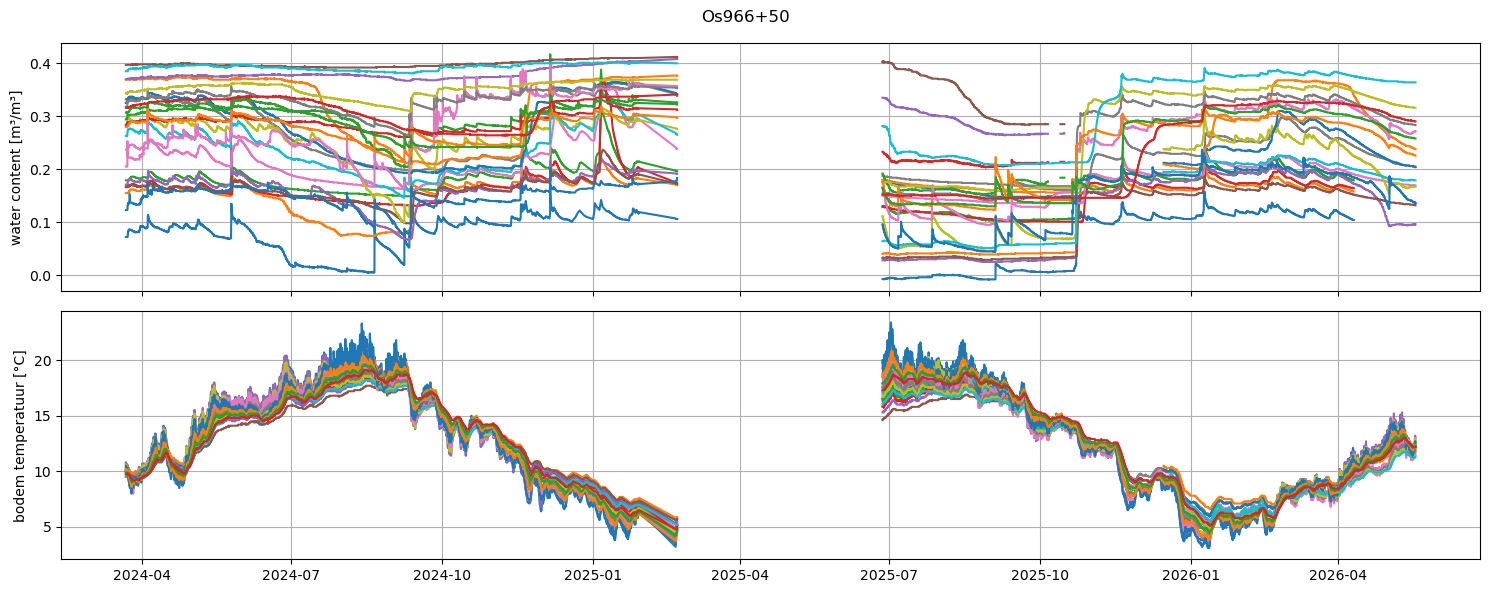

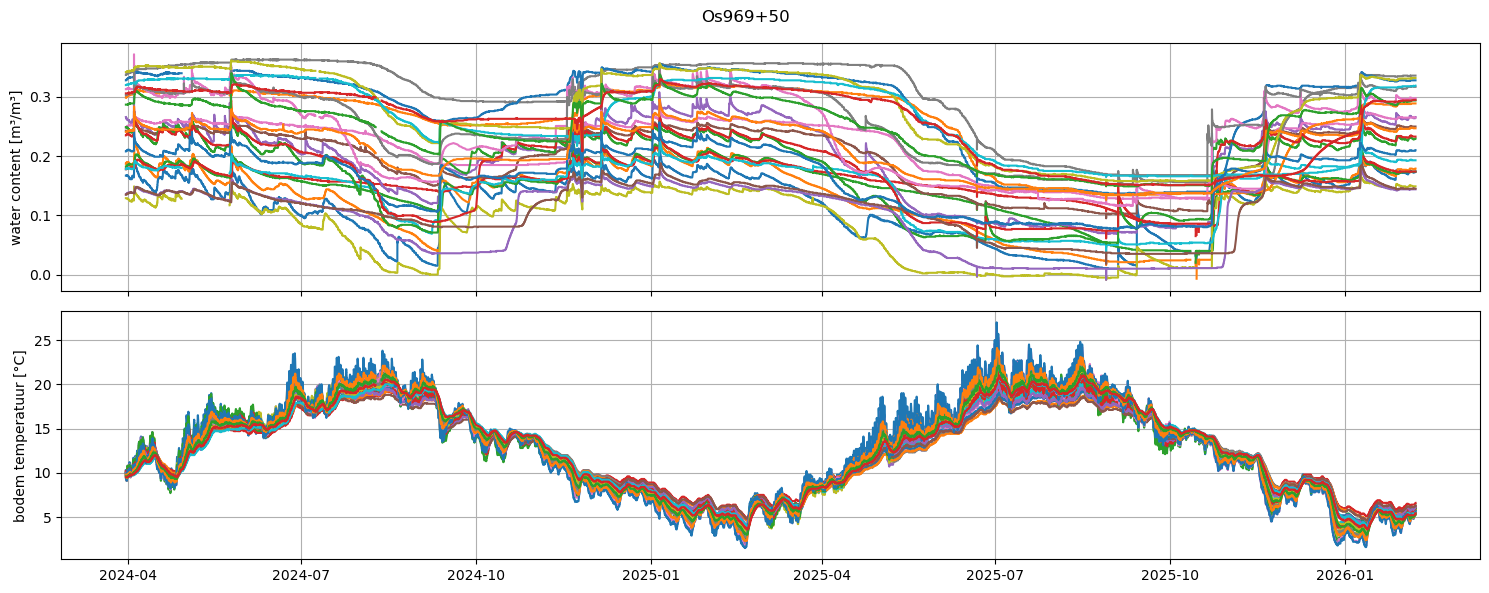

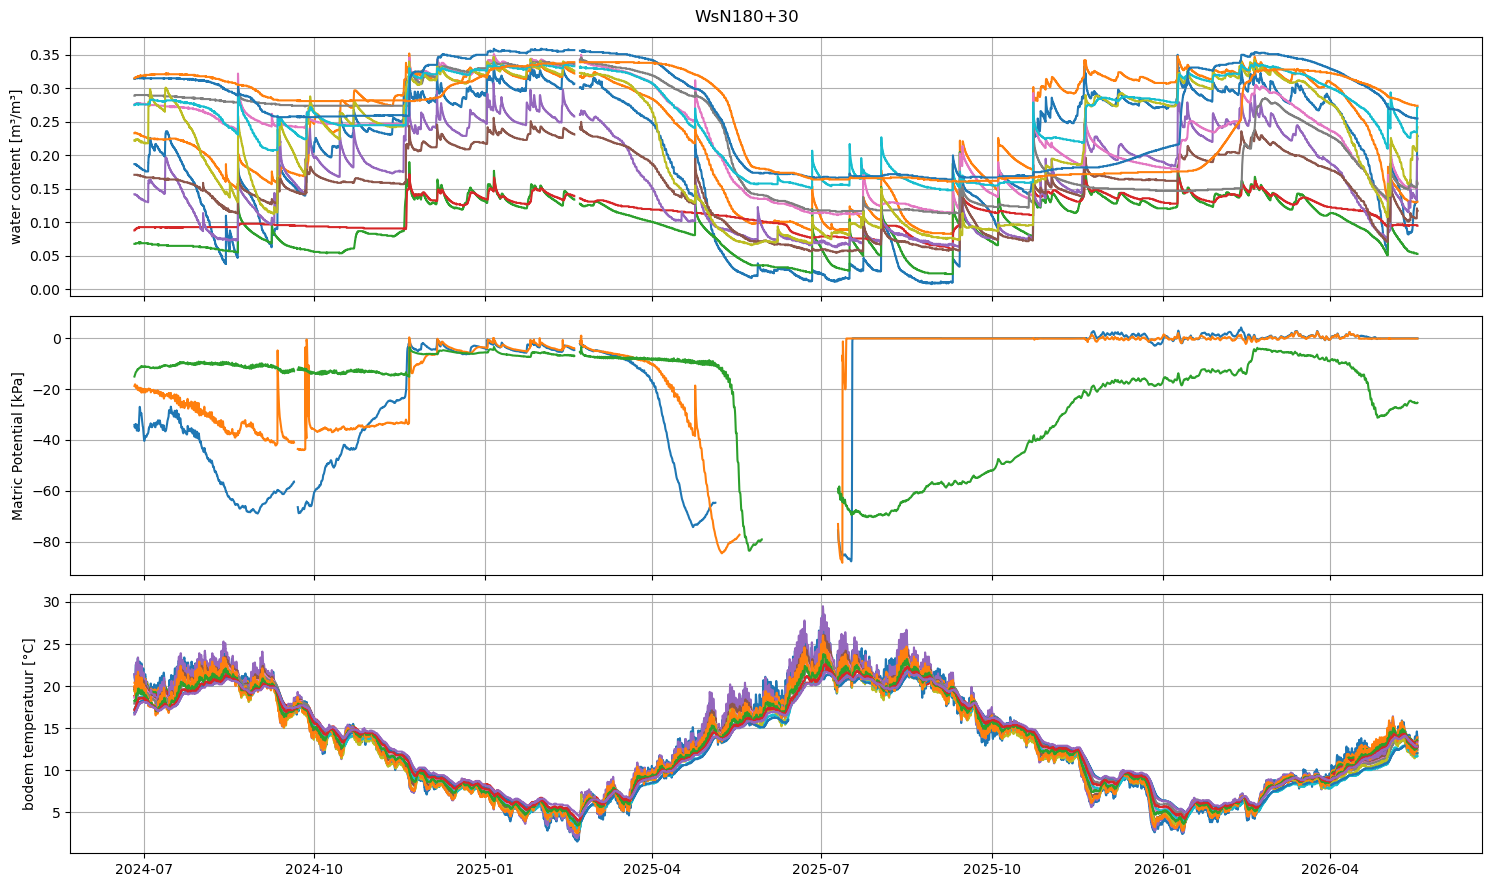

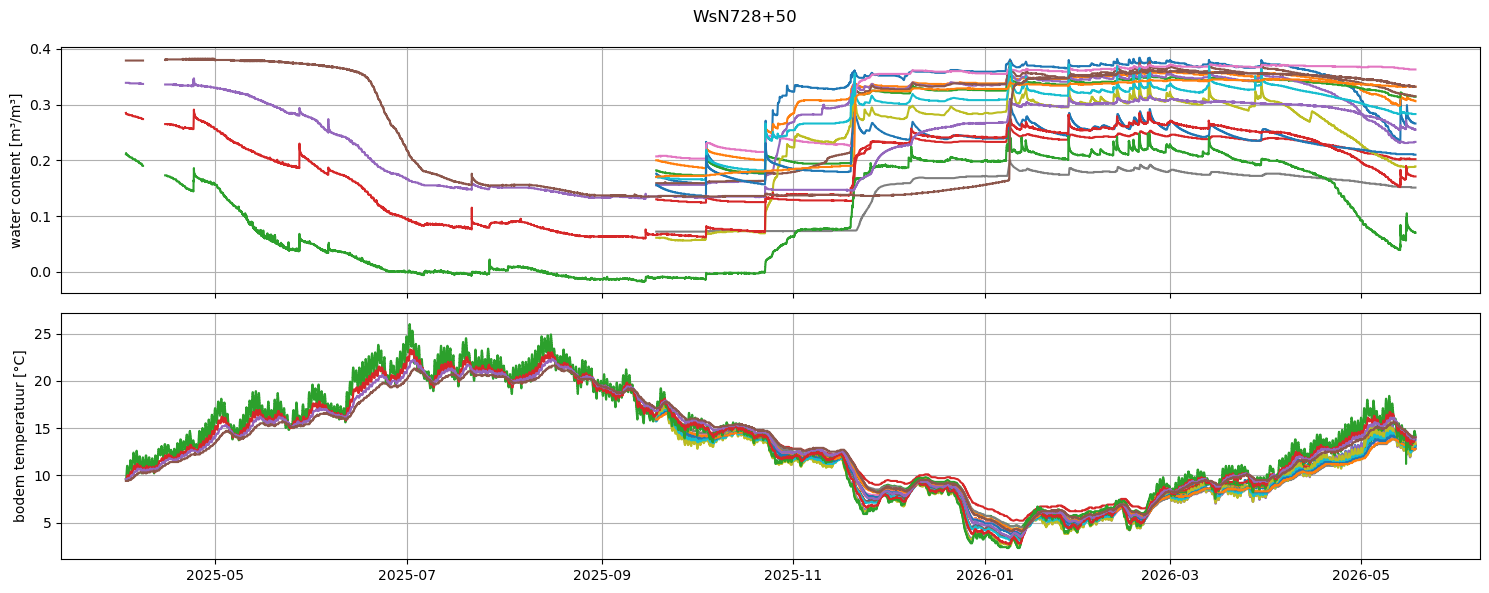

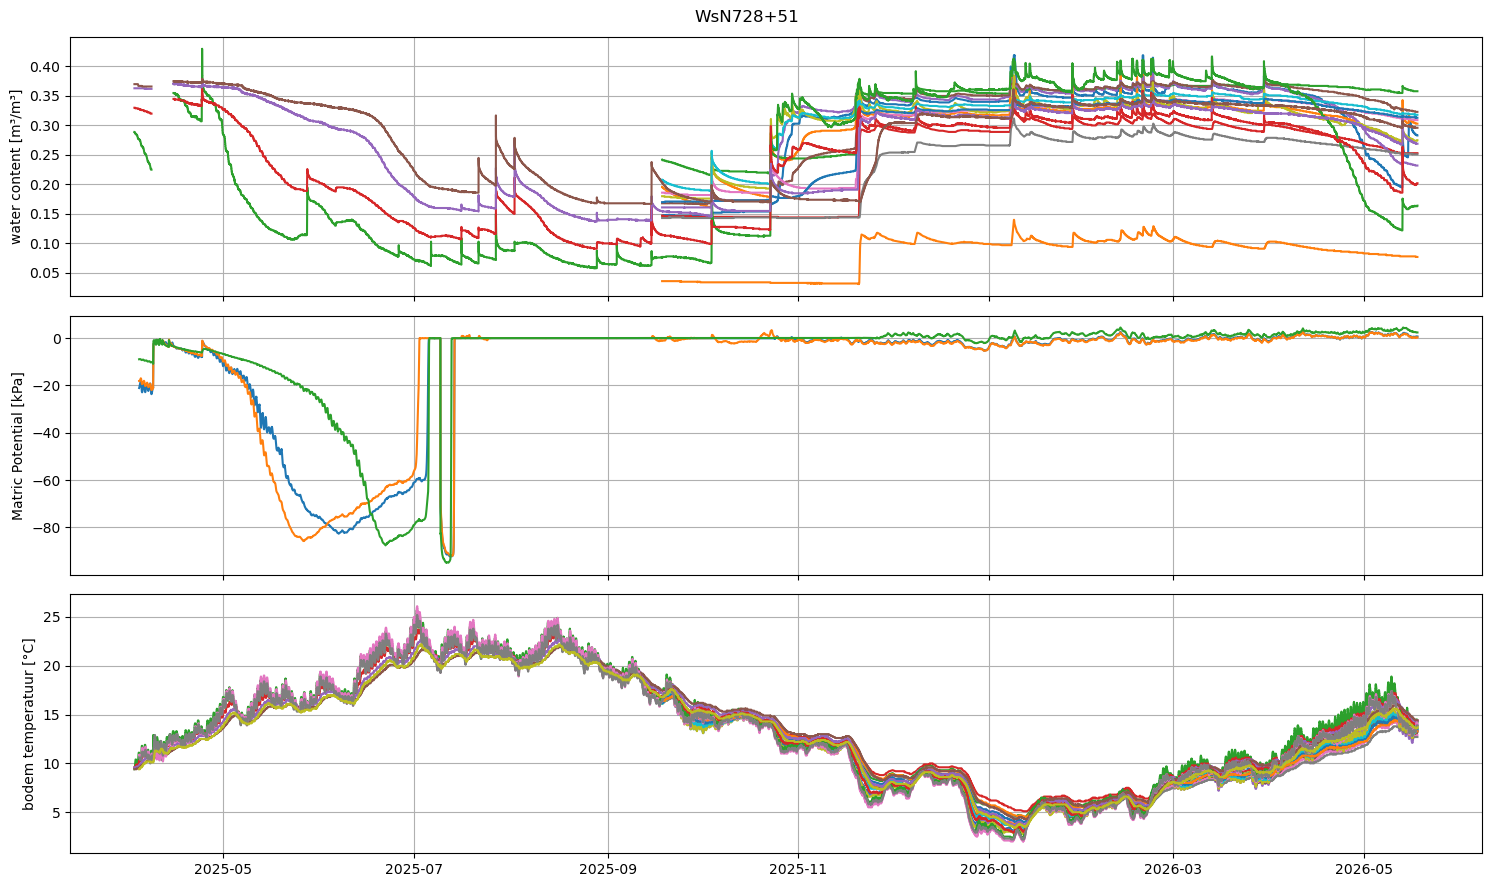

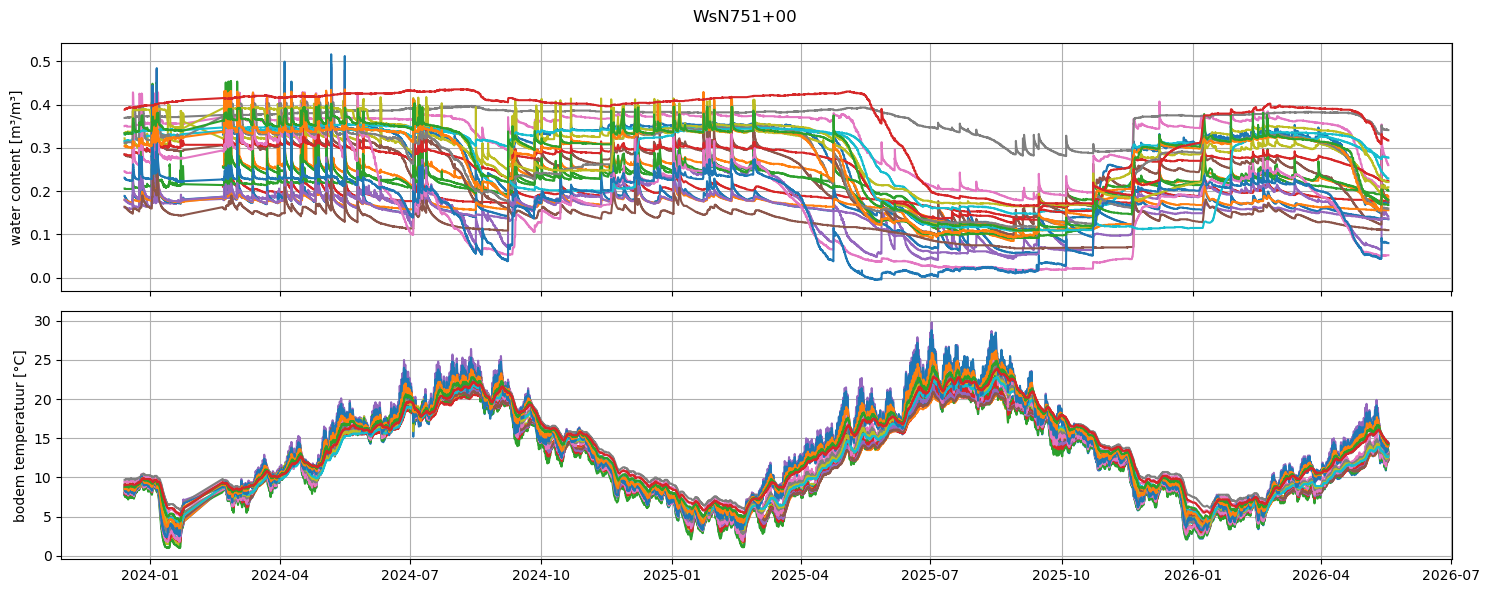

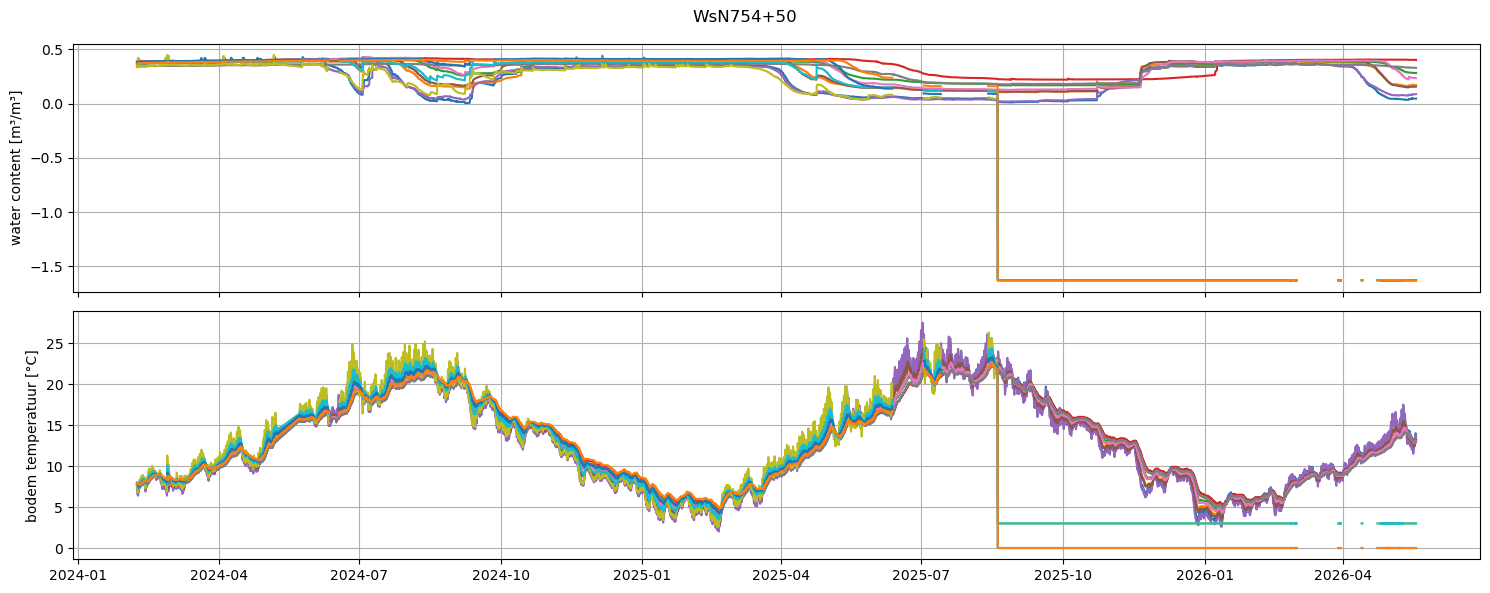

In [11]:
for name_cross_section, oc_cross in oc.groupby('name_cross_section'):
    # loop over all cross sections and make a plot for each cross section

    if 'tensiometer' not in oc_cross.sensor_type.values:
        nrows = 2
    else:
        nrows = 3
    fig, axes = plt.subplots(
        nrows, sharex=True, figsize=(15, nrows*3))
    ax_id = 0

    # water content
    for index, row in oc_cross.loc[oc_cross.sensor_type == 'soil moisture'].iterrows():
        axes[ax_id].plot(
            row.obs.index,
            row.obs.water_content,
        )
    axes[ax_id].set_ylabel('water content [m³/m³]')
    ax_id += 1

    if 'tensiometer'  in oc_cross.sensor_type.values:
        # tensiometers
        for index, row in oc_cross.loc[oc_cross.sensor_type == 'tensiometer'].iterrows():
            axes[ax_id].plot(
                row.obs.index,
                row.obs.matric_potential,
            )
        axes[ax_id].set_ylabel('Matric Potential [kPa]')
        ax_id += 1  

    for index, row in oc_cross.iterrows():
        axes[ax_id].plot(
            row.obs.index,
            row.obs.soil_temperature,
        )
    axes[ax_id].set_ylabel('bodem temperatuur [°C]')

    for ax in axes:
        ax.grid()

    fig.suptitle(name_cross_section, y=0.98)

    fn_save = f'{PLOT_DIR}unsat_quickplot_{name_cross_section.replace(',', '_')}.png'
    fig.tight_layout()
    fig.savefig(fn_save)

## Plot van een locatie maken

Dus van 1 pin, 4 sensoren

In [12]:
oc.name_location.unique()

<StringArray>
[  'Os966,50_BIT1_SM',   'Os966,50_BIT2_SM',   'Os966,50_BIT3_SM',
   'Os966,50_BIT4_SM',   'Os966,50_ITAL_SM',     'Os966,50_KR_SM',
    'Os969,50_BIT_SM',  'Os969,50_ITAL1_SM',  'Os969,50_ITAL2_SM',
  'Os969,50_ITAL3_SM',    'Os969,50_KR1_SM',    'Os969,50_KR2_SM',
  'WsN180,29_ITAL_SM',    'WsN180,29_KR_SM', 'WsN180,29_KR_TM_32',
 'WsN180,29_KR_TM_66', 'WsN180,29_KR_TM_86',    'WsN180,31_KR_SM',
   'WsN728,50_BIT_SM', 'WsN728,50_ITAL1_SM', 'WsN728,50_ITAL2_SM',
    'WsN728,50_KR_SM',   'WsN728,51_BIT_SM', 'WsN728,51_ITAL1_SM',
 'WsN728,51_ITAL2_SM',    'WsN728,51_KR_SM', 'WsN728,52_KR_TM_32',
 'WsN728,52_KR_TM_35', 'WsN728,52_KR_TM_67',   'WsN751,05_BIT_SM',
   'WsN751,05_BUB_SM', 'WsN751,05_ITAL1_SM', 'WsN751,05_ITAL2_SM',
    'WsN751,05_KR_SM',  'WsN751,05_UTAL_SM',    'WsN754,40_KR_SM',
    'WsN754,43_KR_SM',    'WsN754,49_KR_SM']
Length: 38, dtype: str

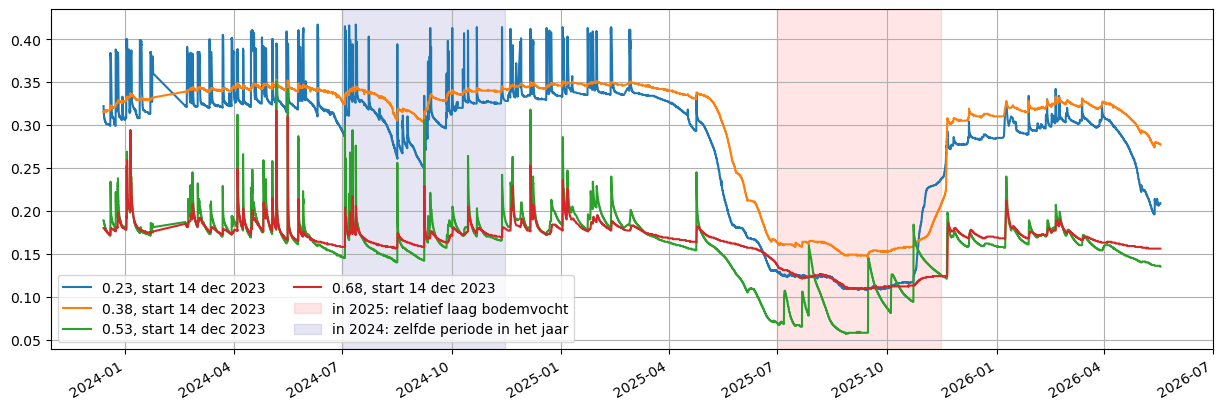

In [13]:
# een plot van een locatie, dus een pin, dan 4 sensoren
fig, ax = plt.subplots(1, figsize=(15, 5))
for index, row in oc.loc[oc.name_location.isin(['WsN751,05_ITAL1_SM',])].iterrows():
    row.obs.water_content.plot(ax=ax, label=f'{row.screen_top}, start {row.obs.dropna().index[0].strftime("%d %b %Y")}')
ax.grid()

ax.axvspan(pd.Timestamp('2025-07-01'), pd.Timestamp('2025-11-15'), color='red', alpha=0.1, label='in 2025: relatief laag bodemvocht')
ax.axvspan(pd.Timestamp('2024-07-01'), pd.Timestamp('2024-11-15'), color='darkblue', alpha=0.1, label='in 2024: zelfde periode in het jaar')
ax.legend(loc='lower left', ncols=2)

## Where are sensors located

In levee profile.

In [14]:
oc.columns

Index(['x', 'y', 'location', 'filename', 'source', 'unit', 'tube_nr',
       'screen_top', 'screen_bottom', 'ground_level', 'tube_top',
       'metadata_available', 'obs', 'name_location', 'name_cross_section',
       'region', 'dp_loggerbox', 'sensor_suffix', 'sensor_dp', 'raai_dp',
       'region_raai_dp', 'distance_to_ref', 'sensor_position_name',
       'sensor_position_id', 'sensor_type',
       'onderzijde_kleilaag_installatie_cm'],
      dtype='str')

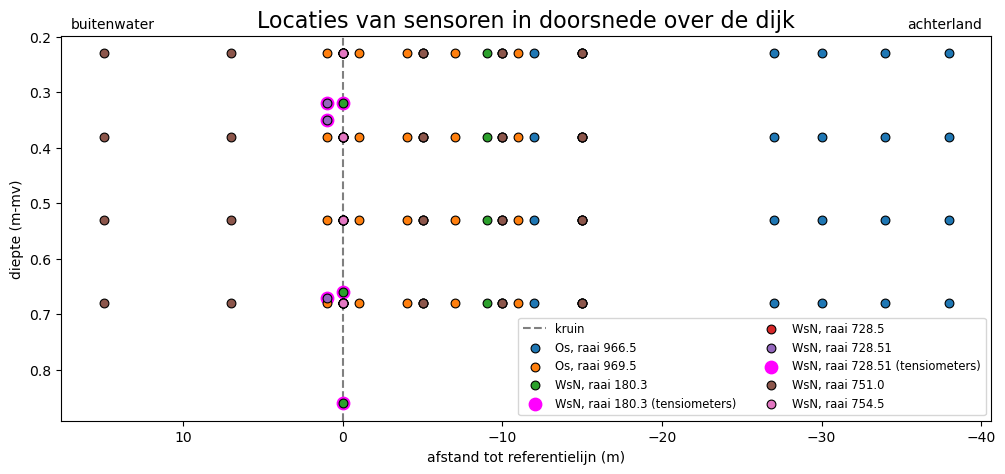

In [15]:
def plot_locations(oc):
    fig, ax = plt.subplots(1, figsize=(12, 5))
    ax.axvline(x=0, color='gray', linestyle='--', label='kruin', zorder=0)
    
    for (region, raai_dp), df_raai_dp in oc.groupby(['region', 'raai_dp']):
        ax.scatter(
            df_raai_dp.distance_to_ref,
            df_raai_dp.screen_top,
            40,
            label=f'{region}, raai {raai_dp}',
            edgecolor='black',
            linewidth=0.8,
        )
        # tensiometers
        df_raai_dp_tensiometer = df_raai_dp[df_raai_dp.sensor_type == 'tensiometer']
        if not df_raai_dp_tensiometer.empty:
            ax.scatter(
                df_raai_dp_tensiometer.distance_to_ref,
                df_raai_dp_tensiometer.screen_top,
                80,
                label=f'{region}, raai {raai_dp} (tensiometers)',
                marker='o',
                color='magenta',
                zorder=0,
            )

    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xlabel('afstand tot referentielijn (m)')
    ax.text(0.01, 1.01, 'buitenwater', transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='left')
    ax.text(0.99, 1.01, 'achterland', transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right')
    ax.set_ylabel('diepte (m-mv)')
    ax.legend(loc='lower right', ncols=2, fontsize='small')
    ax.set_title('Locaties van sensoren in doorsnede over de dijk', fontsize=16)

plot_locations(oc)

In [16]:
oc.columns

Index(['x', 'y', 'location', 'filename', 'source', 'unit', 'tube_nr',
       'screen_top', 'screen_bottom', 'ground_level', 'tube_top',
       'metadata_available', 'obs', 'name_location', 'name_cross_section',
       'region', 'dp_loggerbox', 'sensor_suffix', 'sensor_dp', 'raai_dp',
       'region_raai_dp', 'distance_to_ref', 'sensor_position_name',
       'sensor_position_id', 'sensor_type',
       'onderzijde_kleilaag_installatie_cm'],
      dtype='str')

# Analyse different locations

In [26]:
def plot_per_depth(oc, screen_top_between=[0.6, 0.7], sensor_position_contains=None, raai_dp=None, sensor_type='soil moisture', tmin=None, tmax=None):
    # plot timeseries with same sensor depth
    fig, ax = plt.subplots(1, figsize=(12, 5))


    if sensor_position_contains is not None:
        oc_plot = oc.loc[
            (oc.screen_top >= screen_top_between[0]) &
            (oc.screen_top <= screen_top_between[1]) &
            (oc.sensor_position_name.str.contains(sensor_position_contains)) &
            (oc.sensor_type == sensor_type)
        ].sort_values('raai_dp', ascending=False)   
        # assign unique color per raai_dp
        raai_dp_list = oc_plot.raai_dp.unique()
        color_map = dict(zip(raai_dp_list, plt.cm.tab10.colors[:len(raai_dp_list)]))

        for index, row in oc_plot.iterrows():
            color = color_map.get(row.raai_dp, 'blue')
            df = row.obs[tmin:tmax].water_content
            if df.empty:
                continue
            df.plot(
                ax=ax,
                label=f'{row.region}, raai {row.raai_dp}, pos {row.sensor_position_name}',
                linestyle='-',
                linewidth=1,
                color=color
            )
        title_str = f'{sensor_type.capitalize()} sensors in {sensor_position_contains} with depth {screen_top_between[0]}-{screen_top_between[1]} m-surface level'
    elif raai_dp is not None:
        oc_plot = oc.loc[
            (oc.screen_top >= screen_top_between[0]) &
            (oc.screen_top <= screen_top_between[1]) &
            (oc.raai_dp == raai_dp) &
            (oc.sensor_type == sensor_type)
        ].sort_values('distance_to_ref', ascending=True)   
        
        # assign unique color per sensor_position_name
        sensor_positions = oc_plot.sensor_position_name.unique()
        color_map = dict(zip(sensor_positions, plt.cm.tab10.colors[:len(sensor_positions)]))

        for index, row in oc_plot.iterrows():
            color = color_map.get(row.sensor_position_name, 'blue')
            df = row.obs[tmin:tmax].water_content
            if df.empty:
                continue
            df.plot(
                ax=ax,
                label=f'{row.region}, raai {row.raai_dp}, pos {row.sensor_position_name}',
                linestyle='-',
                linewidth=1,
                color=color
                )
        title_str = f'{sensor_type.capitalize()} sensors in raai {raai_dp} with depth {screen_top_between[0]}-{screen_top_between[1]} m-surface level'
    

    ax.grid()
    ax.set_ylim(0, 0.5)

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    ax.set_title(title_str)

    return fig, ax

(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'Soil moisture sensors in KR with depth 0.6-0.7 m-surface level'}>)

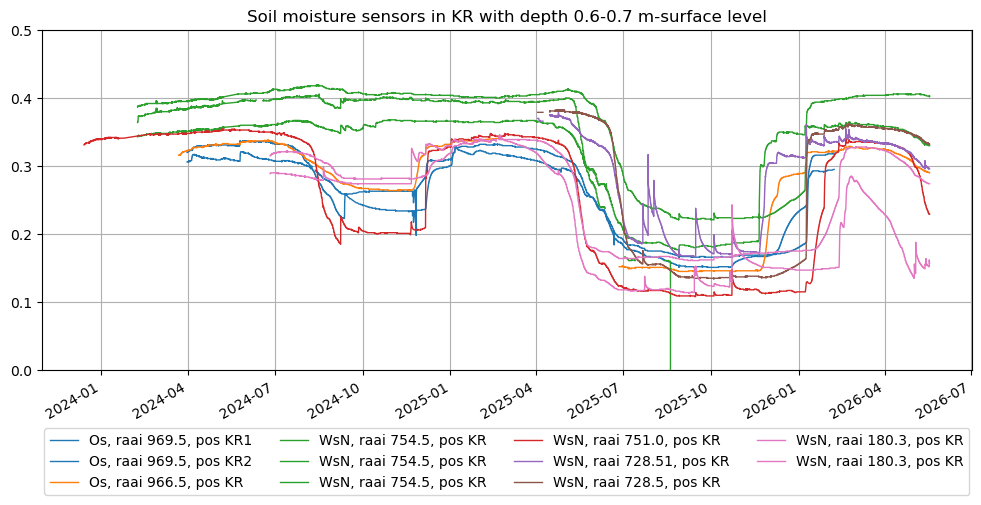

In [27]:
#plot_per_depth(oc.loc[oc.region.isin(['WsN',])], sensor_position_contains='KR')
plot_per_depth(oc, sensor_position_contains='KR')

(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'Soil moisture sensors in KR with depth 0.4-0.7 m-surface level'}>)

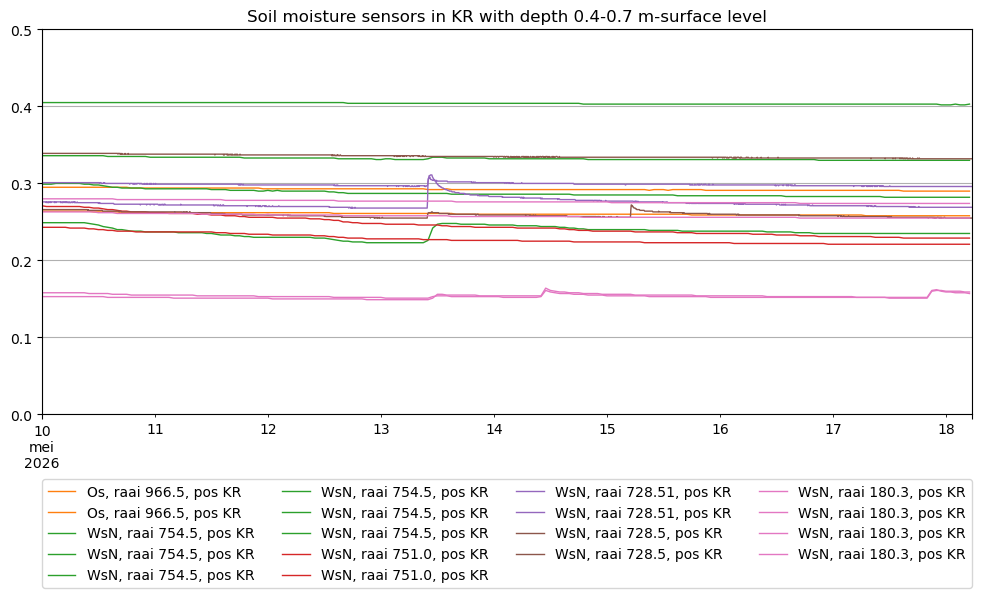

In [33]:
plot_per_depth(oc, sensor_position_contains='KR', tmin=pd.Timestamp('2026-05-10'), screen_top_between=[0.4, 0.7])

(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'Soil moisture sensors in KR with depth 0.6-0.7 m-surface level'}>)

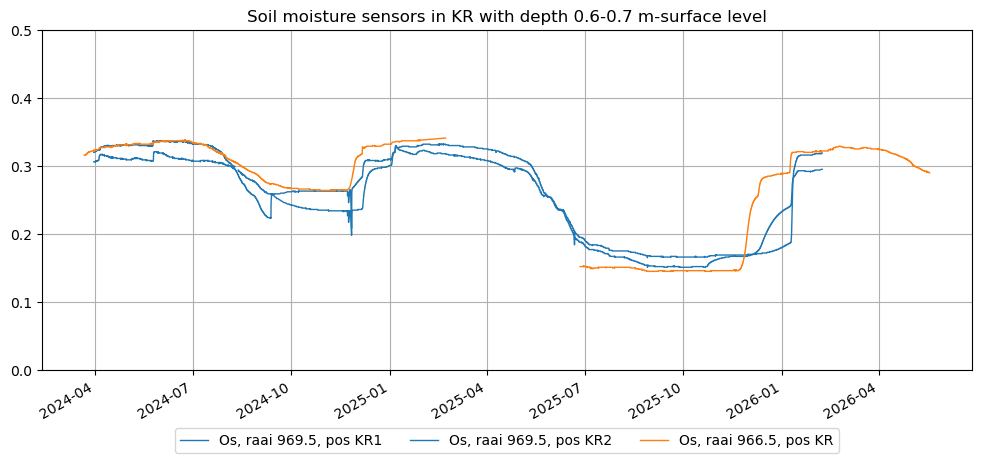

In [34]:
plot_per_depth(oc.loc[oc.region.isin(['Os',])], sensor_position_contains='KR')

(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'Soil moisture sensors in raai 751 with depth 0.6-0.7 m-surface level'}>)

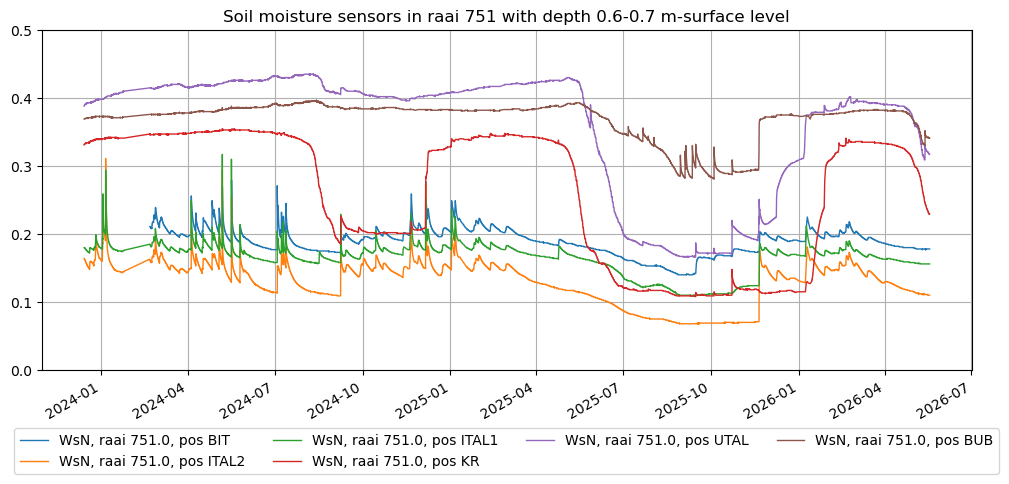

In [35]:
plot_per_depth(oc.loc[oc.region.isin(['WsN',])], raai_dp=751)

(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'Soil moisture sensors in raai 754.5 with depth 0.6-0.7 m-surface level'}>)

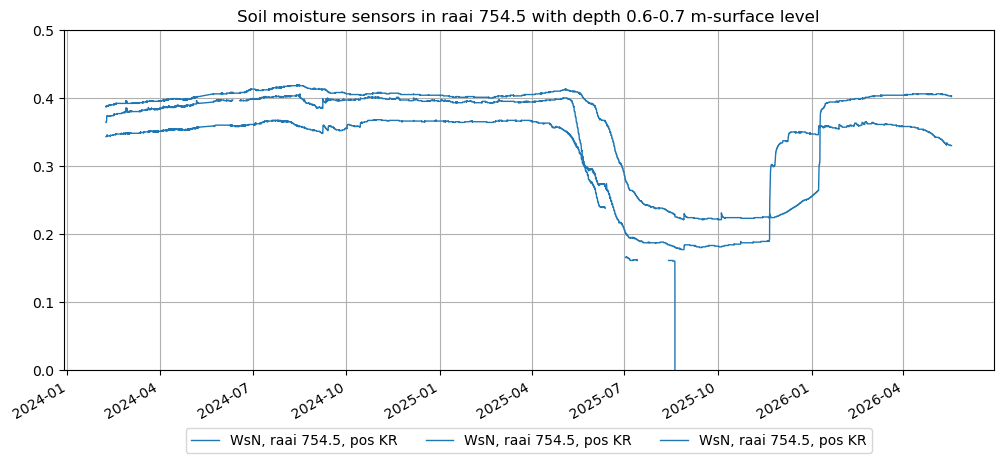

In [36]:
plot_per_depth(oc.loc[oc.region.isin(['WsN',])], raai_dp=754.5)

# Results per depth

In [37]:
oc.screen_bottom.value_counts()

screen_bottom
0.23    32
0.38    32
0.53    32
0.68    32
0.32     2
0.66     1
0.86     1
0.35     1
0.67     1
Name: count, dtype: int64

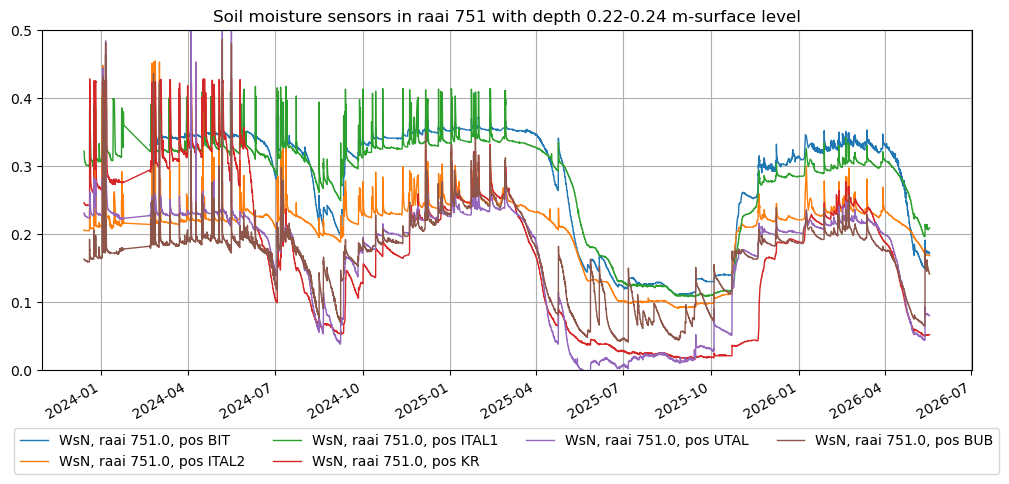

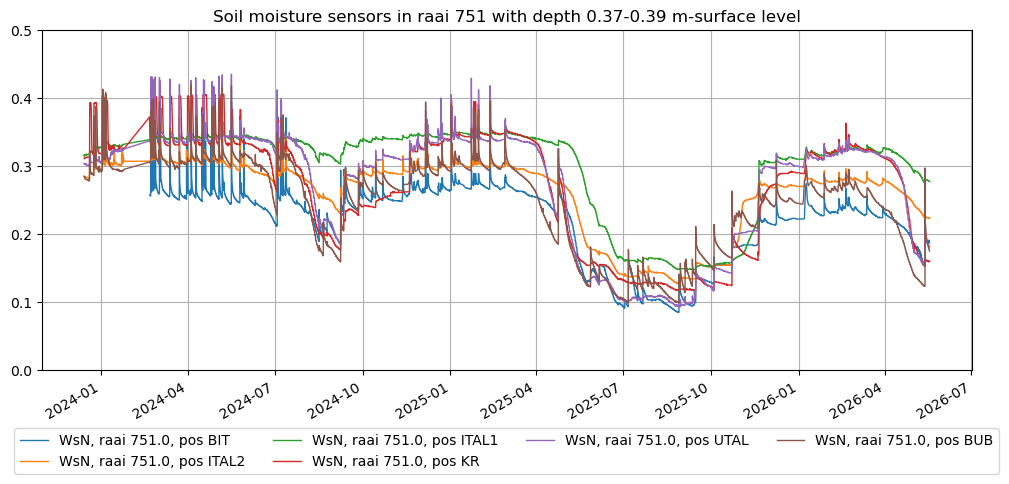

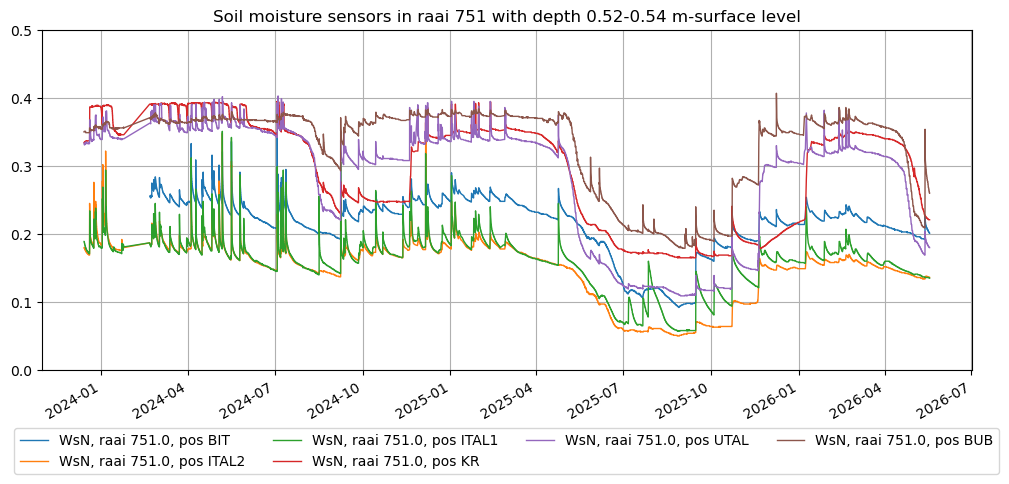

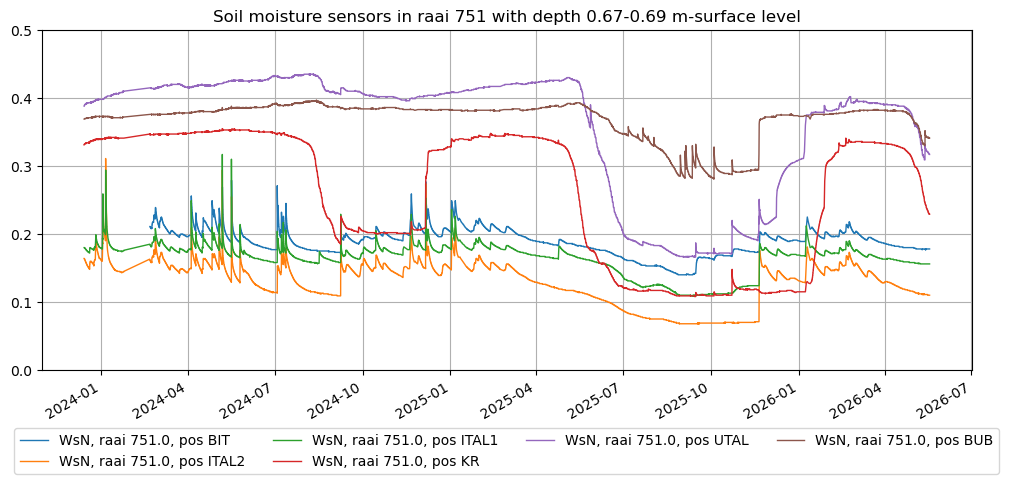

In [38]:
import numpy as np
for screen_upper in np.arange(0.22, 0.8, 0.15):
    plot_per_depth(oc.loc[oc.region.isin(['WsN',])], raai_dp=751, screen_top_between=[np.round(screen_upper, 2), screen_upper+0.02])

In [46]:
def fig_location_in_cols_depths_in_rows(oc, region=None, dp=None, ylim=[0, 0.45], suptitle_prefix=None, vspans=None, vspan_colors=None, vspan_labels=None, suptitle_message=None, tmin=None, tmax=None):
    if (region is not None) & (dp is not None):
        oc = oc.loc[
            (oc.raai_dp == dp) &
            (oc.region == region)]
        suptitle_prefix = f', {region} dp={dp}'
    else:
        suptitle_prefix = ''


    locations = oc.sort_values('distance_to_ref').name_location.unique()
    depths = np.sort(oc.screen_top.unique())

    fig, axes = plt.subplots(len(depths), len(locations), figsize=(4*len(locations), 3*len(depths)), sharex=True, sharey=True)

    for i, depth in enumerate(depths):
        for j, loc in enumerate(locations):
            ax = axes[i, j] if len(depths) > 1 else axes[j]
            subset = oc[(oc.name_location == loc) & (oc.screen_top == depth)]
            for idx, row in subset.iterrows():
                df = row.obs[tmin:tmax].water_content
                if df.empty:
                    continue
                df.plot(ax=ax, label=idx)
            if i == 0:
                ax.set_title(loc)
            if j == 0:
                ax.set_ylabel(f"Depth: {depth:.2f} m")
            ax.grid()
            if i == len(depths)-1:
                ax.set_xlabel("")
            #if j == len(locations)-1:
            #    ax.legend(fontsize='small')

            if vspans is not None:
                for vspan, color, label in zip(vspans, vspan_colors, vspan_labels):
                    ax.axvspan(pd.Timestamp(vspan[0]), pd.Timestamp(vspan[1]), color=color, alpha=0.1, label=label)

    xmin = np.max([oc.stats.get_first_last_obs_date().iloc[:,0].min(), pd.Timestamp(tmin)]) if tmin is not None else oc.stats.get_first_last_obs_date().iloc[:,0].min()
    xmax = np.min([oc.stats.get_first_last_obs_date().iloc[:,1].max(), pd.Timestamp(tmax)]) if tmax is not None else oc.stats.get_first_last_obs_date().iloc[:,1].max()
    axes[0,0].set_xlim(xmin, xmax)
    axes[0,0].set_ylim(ylim)

    fig.suptitle(f"Soil moisture timeseries per location and depth{suptitle_prefix}{suptitle_message if suptitle_message is not None else ''}", fontsize=16, y=1.02)

    return fig, axes

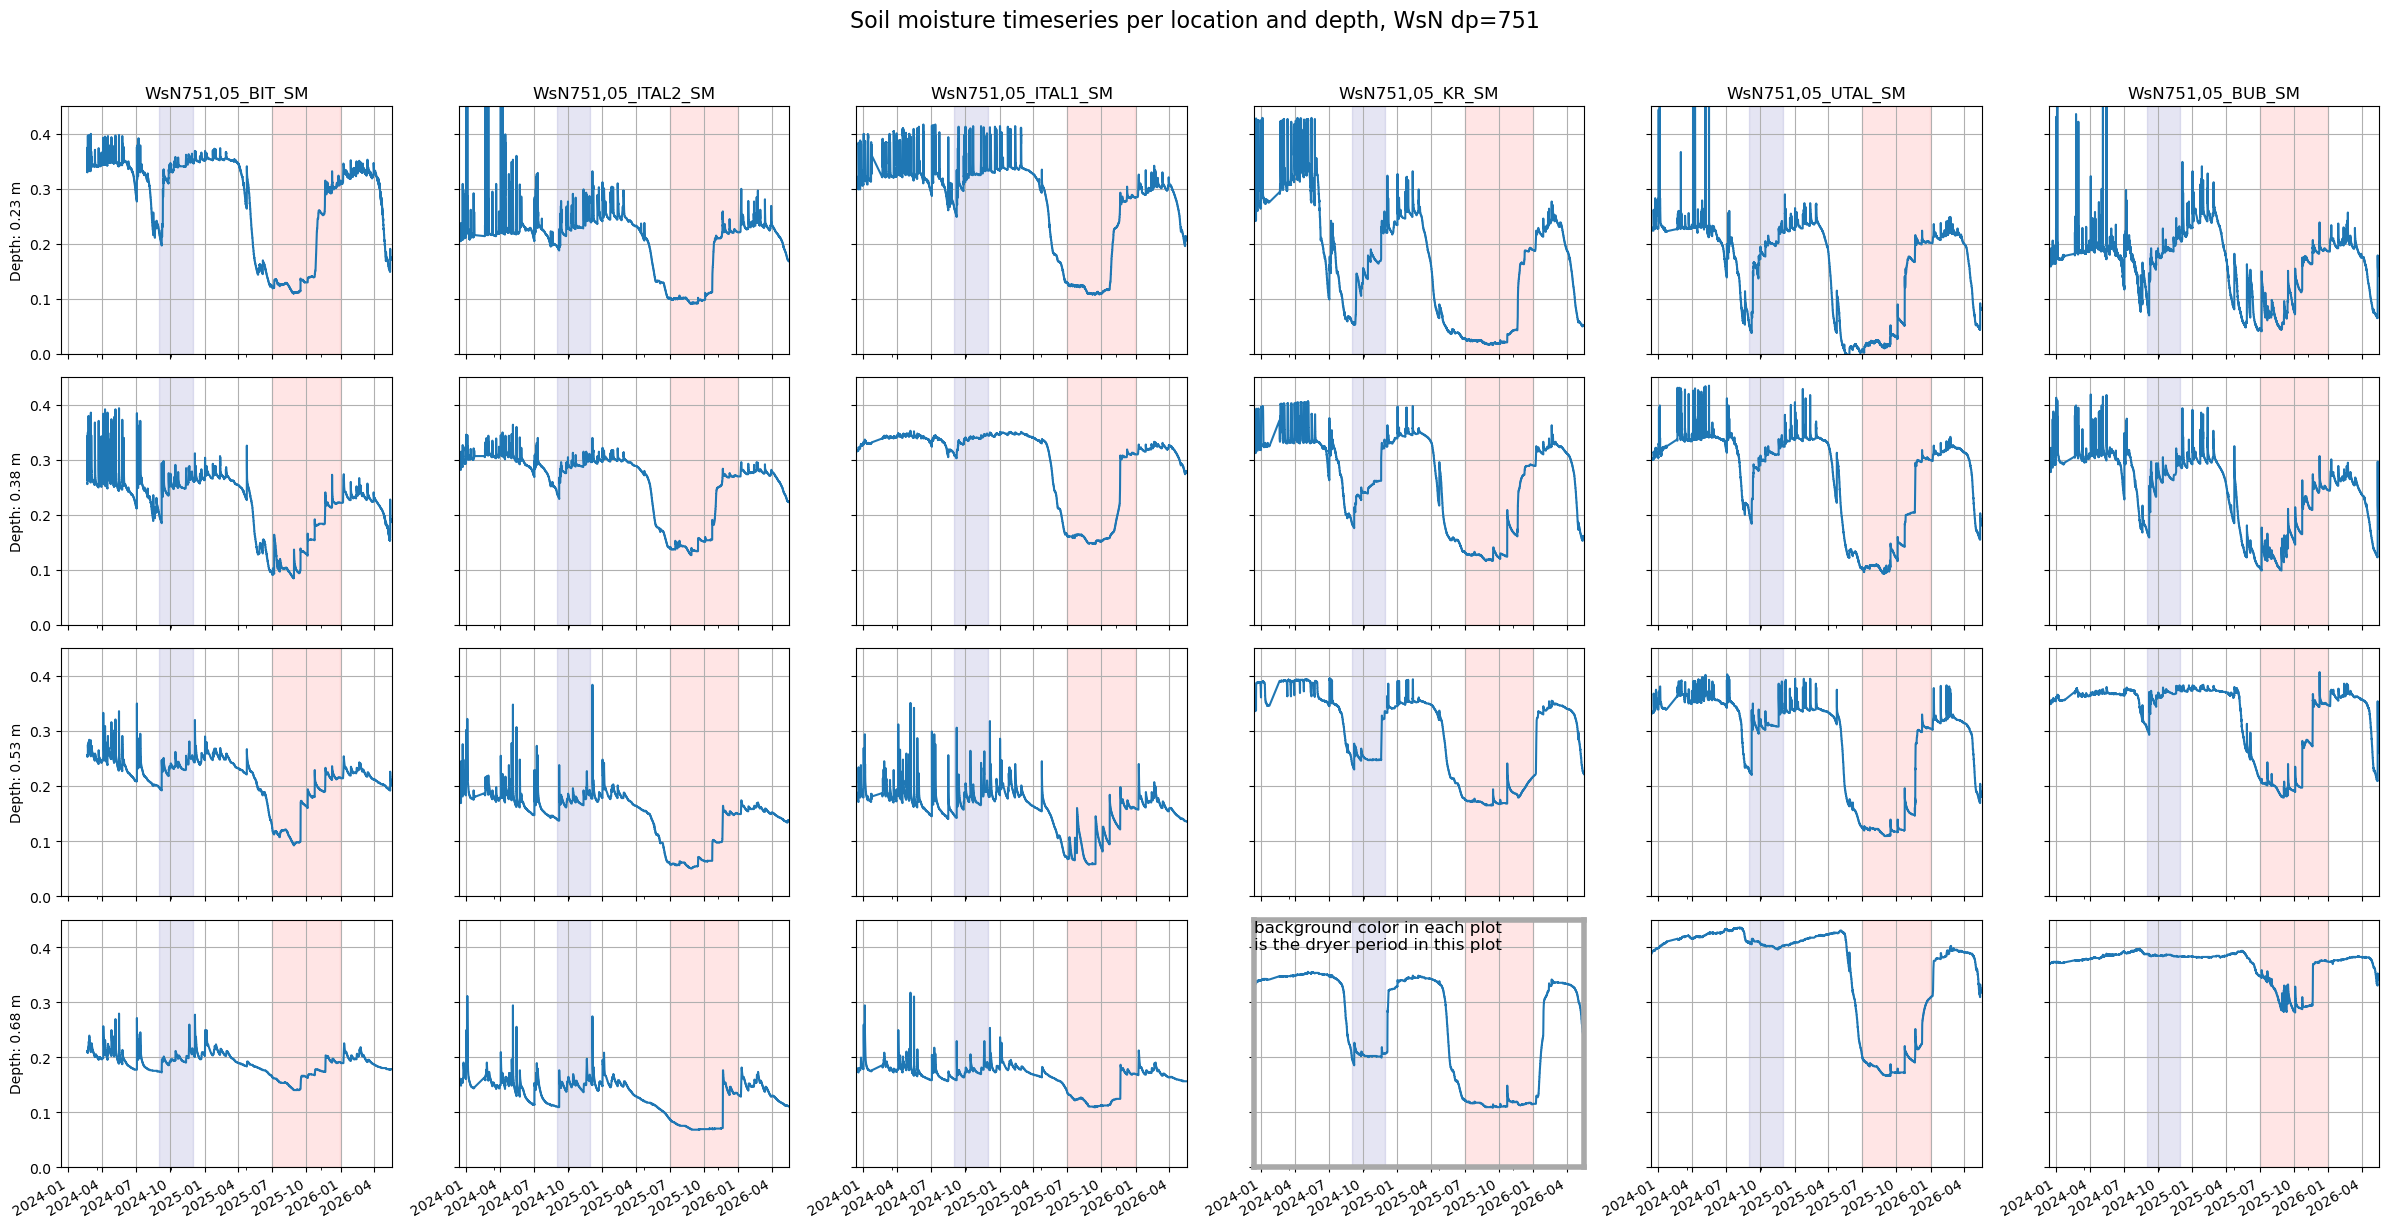

In [42]:
fig, axes = fig_location_in_cols_depths_in_rows(
    oc, region='WsN', dp=751, 
    vspans=[('2024-09-01', '2024-11-30'), ('2025-07-01', '2025-12-31')], vspan_colors=['darkblue', 'red'], vspan_labels=['in 2024: zelfde periode in het jaar', 'in 2025: relatief laag bodemvocht'],
)
for side in ['top', 'right', 'bottom', 'left']:
    axes[3, 3].spines[side].set_color('darkgray')
    axes[3, 3].spines[side].set_linewidth(4)
axes[3, 3].set_zorder(10)
axes[3, 3].text(0, 1, 'background color in each plot\nis the dryer period in this plot', transform=axes[3, 3].transAxes, fontsize=12, verticalalignment='top')

fig.tight_layout()
fig.savefig(f'{PLOT_DIR}col_rows_WsN_dp751.png')

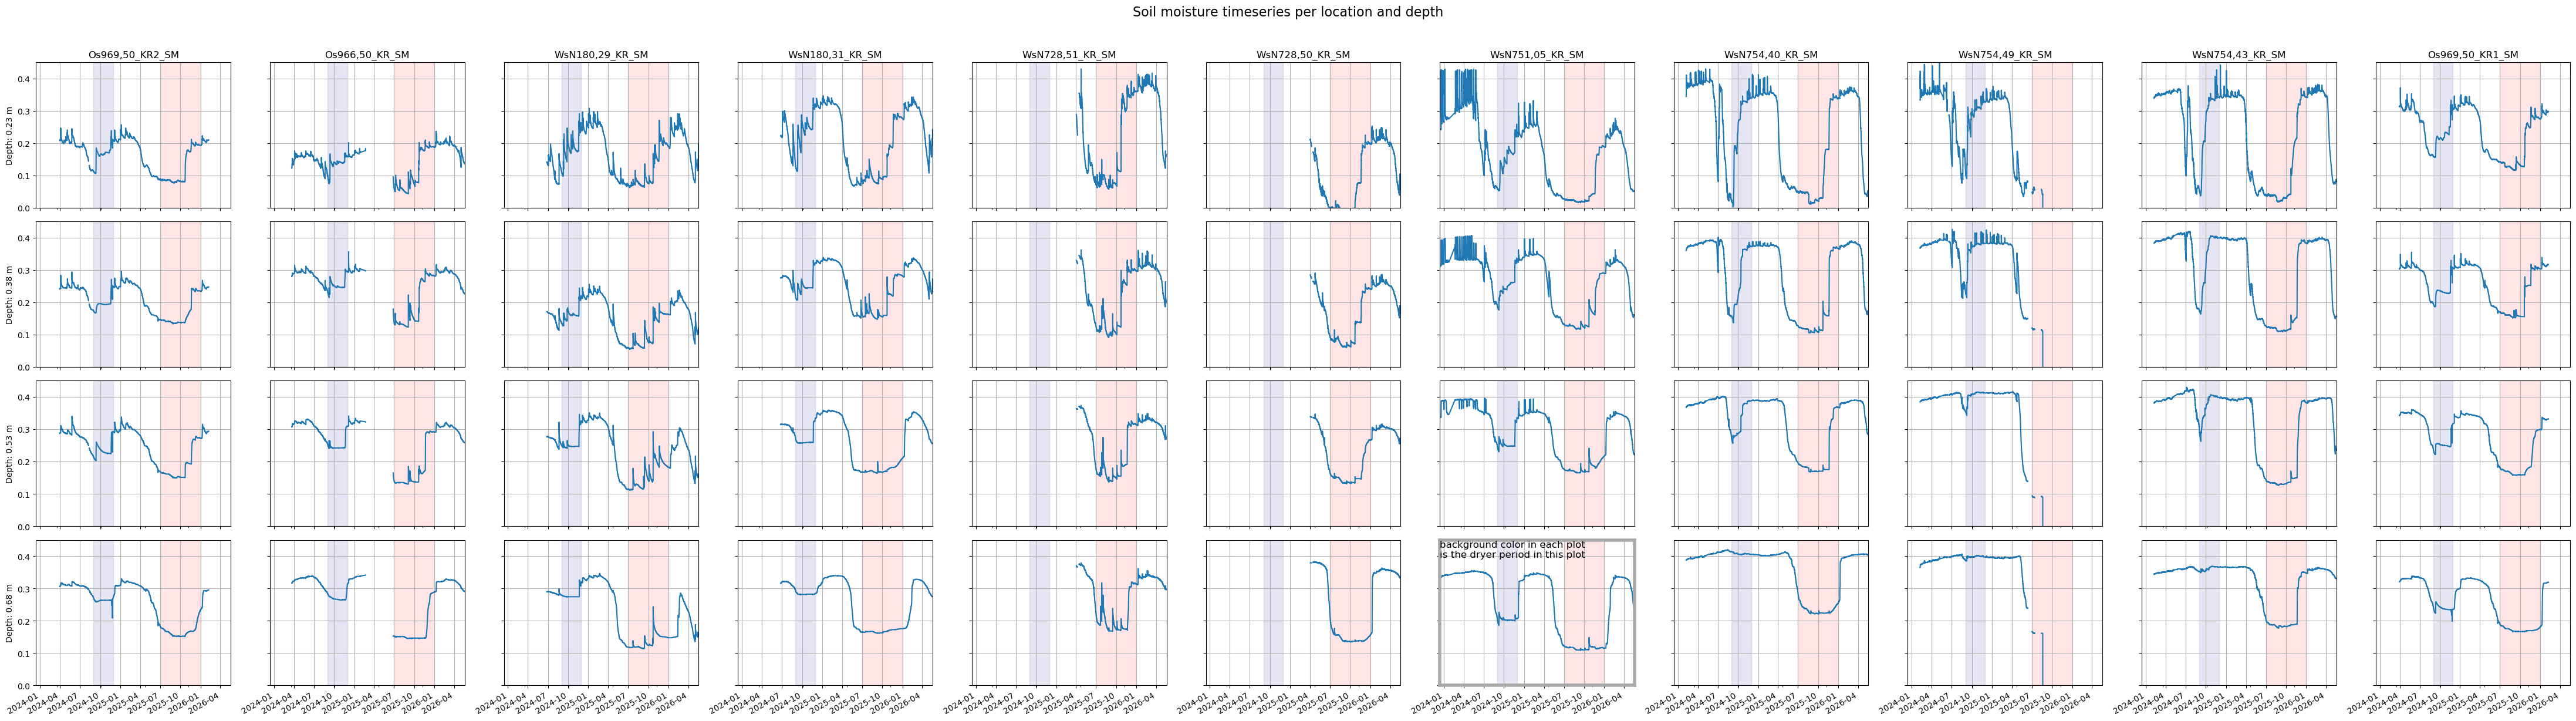

In [43]:
fig, axes = fig_location_in_cols_depths_in_rows(
    oc.loc[oc.sensor_position_name.str.contains('KR') & oc.sensor_type.eq('soil moisture')], 
    vspans=[('2024-09-01', '2024-11-30'), ('2025-07-01', '2025-12-31')], vspan_colors=['darkblue', 'red'], vspan_labels=['in 2024: zelfde periode in het jaar', 'in 2025: relatief laag bodemvocht'],
)
for side in ['top', 'right', 'bottom', 'left']:
    axes[3, 6].spines[side].set_color('darkgray')
    axes[3, 6].spines[side].set_linewidth(4)
axes[3, 6].set_zorder(10)
axes[3, 6].text(0, 1, 'background color in each plot\nis the dryer period in this plot', transform=axes[3, 6].transAxes, fontsize=12, verticalalignment='top')

fig.tight_layout()
fig.savefig(f'{PLOT_DIR}col_rows_all_crest.png')

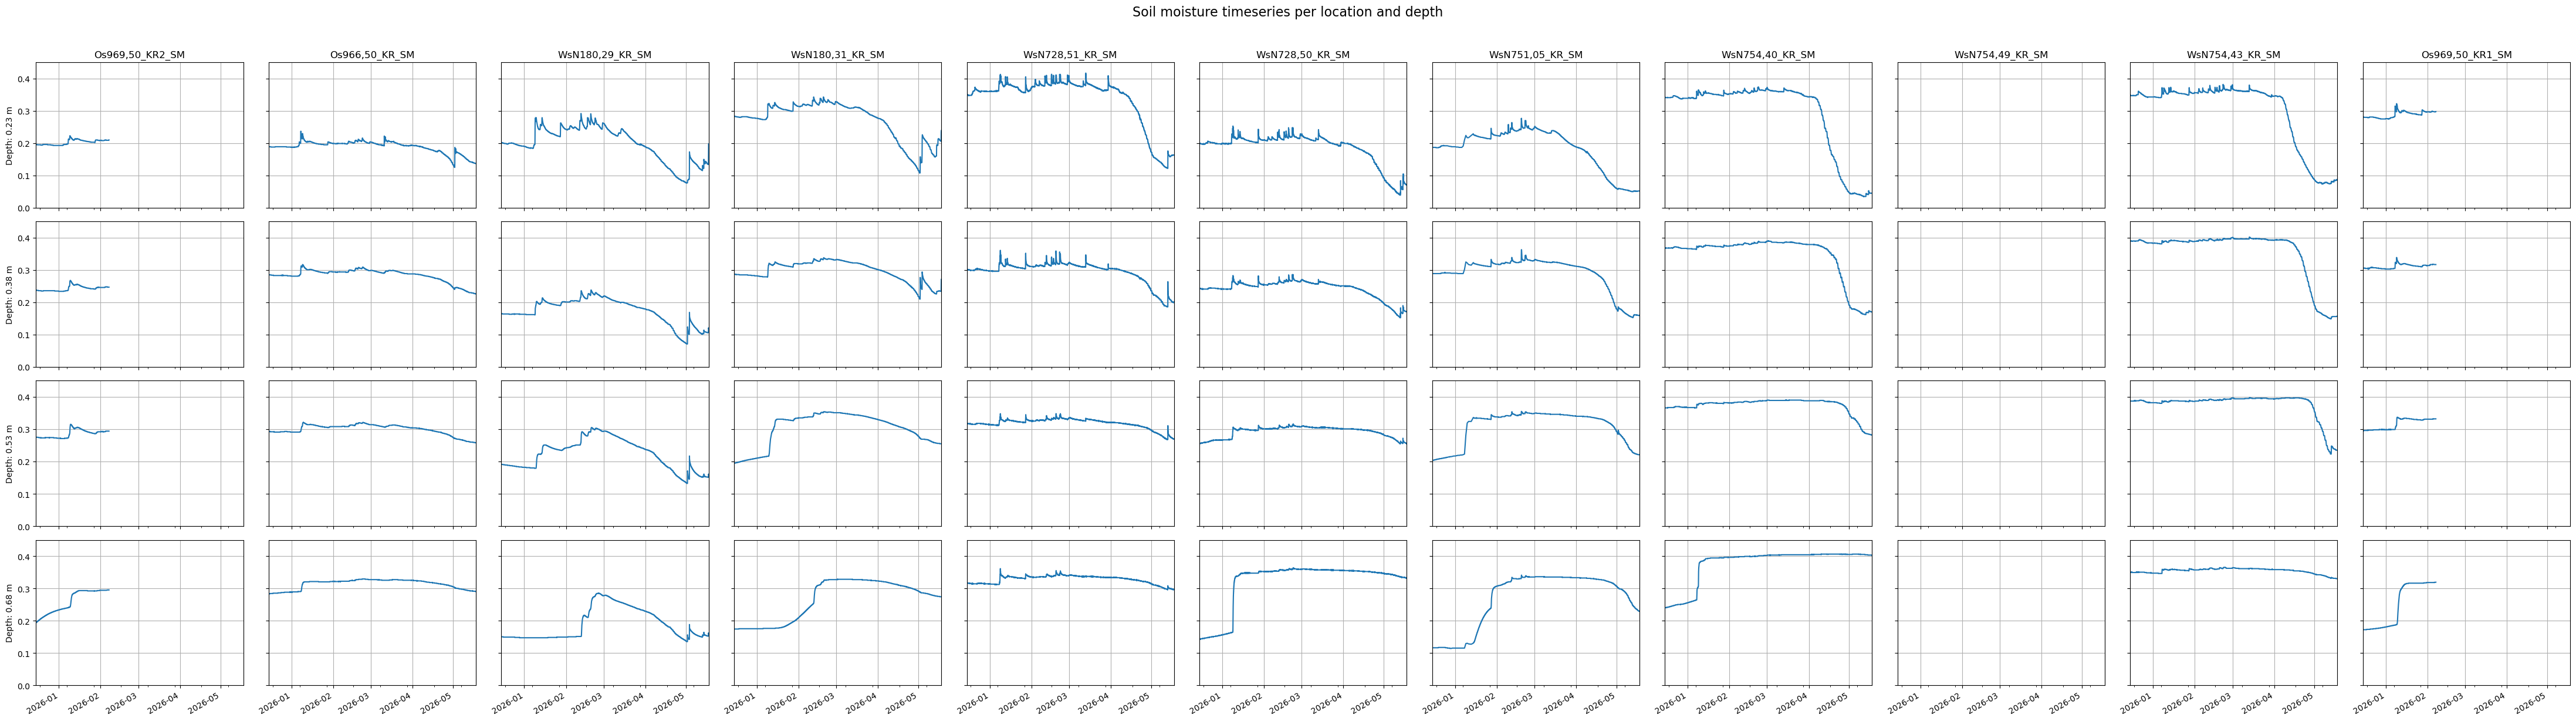

In [47]:
fig, axes = fig_location_in_cols_depths_in_rows(
    oc.loc[oc.sensor_position_name.str.contains('KR') & oc.sensor_type.eq('soil moisture')], 
    #vspans=[('2024-09-01', '2024-11-30'), ('2025-07-01', '2025-12-31')], vspan_colors=['darkblue', 'red'], vspan_labels=['in 2024: zelfde periode in het jaar', 'in 2025: relatief laag bodemvocht'],
    tmin=pd.Timestamp('2025-12-15'), tmax=pd.Timestamp('2026-05-18'),
)

fig.tight_layout()
fig.savefig(f'{PLOT_DIR}col_rows_all_crest_recent.png')